In [ ]:
%load_ext autoreload
%autoreload 2

from tasks.autoencoder import AETask
import os
import torch
from tqdm import tqdm
import einx
from sentence_transformers import SentenceTransformer
from sentence_transformers.models import Pooling, Transformer, Normalize
from transformers import AutoModel, AutoTokenizer, T5TokenizerFast, AutoModelForCausalLM, T5Tokenizer, GPT2LMHeadModel
from datasets import load_dataset, load_from_disk
import re
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
from data.datasets import WikipediaDataset, WikipediaDatasetConfig
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, models
import wandb
from tasks.dlclm import DLCLMTask, InfoLabel
from mauve import compute_mauve, get_features_from_input
from model.encoder import HSEMHead, HSEMHeadConfig, SEMHeadConfig, SEMHead
import os
from data.datasets import FineWebDataset
from transformers import GenerationConfig
from tasks.utils import *
import matplotlib.pyplot as plt
from tasks.ri import RITask

/home/mila/l/leo.gagnon/sentence_diffusion/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
task = RITask.load_from_checkpoint(
    os.path.join(
        os.environ["LOG_DIR"],
        "checkpoints/",
        "zu0ygi15",
        "last.ckpt",
    ),
    strict=False,
    map_location=torch.device("cpu"),
)
task.setup()
task = task.to(device=torch.device("cuda"), dtype=torch.bfloat16)
task.cfg.batch_size = 128

No sentence-transformers model found with name microsoft/deberta-v3-large. Creating a new one with mean pooling.
/home/l/leog/links/scratch/sentence_diffusion/venv/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
You are trying to use a model that was created with Sentence Transformers version 5.1.2, but you're currently using version 5.1.1. This might cause unexpected behavior or errors. In that case, try to update to the latest version.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/824 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/828 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [3]:
batch = next(iter(task.val_dataloader()))

You're using a GPT2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


In [4]:
prompt = [
    batch["input_ids_dec"][i][
        (batch["info_mask_dec"][i] == InfoLabel.PROMPT.value)
    ].tolist()
    for i in range(len(batch["input_ids_dec"]))
]
dlc = torch.stack([
    batch["input_ids_dec"][i][
        (batch["info_mask_dec"][i] == InfoLabel.DLC.value)
    ]
    for i in range(len(batch["input_ids_dec"]))
]).cuda()
true_cont_str = task.decoder.tokenizer.batch_decode([
    batch["input_ids_dec"][i][
        (batch["info_mask_dec"][i] == InfoLabel.CONT.value)
    ].tolist()
    for i in range(len(batch["input_ids_dec"]))
], skip_special_tokens=True)
prompt_str = task.decoder.tokenizer.batch_decode(prompt, skip_special_tokens=True)

In [5]:
prompt_same = [prompt[0] for _ in range(10)]

In [7]:
len(prompt)

128

In [5]:
continuations = task.decoder.tokenizer.batch_decode(
    task.decoder.generate(
        prompt=prompt,
        #dlc=torch.stack([dlc[0] for _ in range(10)]),
        max_length=task.dataset.max_length,
        gen_dlc_len=task.encoder.sem.dlc_len if not task.ar_baseline else None,
        gen_kwargs_dlc={"do_sample": True, "temperature": 1.0},
        gen_kwargs={"do_sample": True, "temperature": 1.0},
    ),
    skip_special_tokens=True,
)

In [66]:
prompt_baseline = [p[:-1] for p in prompt_same]

In [4]:
dl = iter(task.val_dataloader())

In [10]:
for i in tqdm(range(40)):
    batch = next(dl)
    prompt = [
        batch["input_ids_dec"][i][
            (batch["info_mask_dec"][i] == InfoLabel.PROMPT.value)
        ].tolist()
        for i in range(len(batch["input_ids_dec"]))
    ]
    prompt_str = task.decoder.tokenizer.batch_decode(prompt, skip_special_tokens=True)

    with torch.inference_mode():
        continuations = task.decoder.tokenizer.batch_decode(
            task.decoder.generate(
                prompt=prompt,
                max_length=task.cfg.suffix_len,
                gen_dlc_len=task.encoder.sem.dlc_len if not task.ar_baseline else None,
                gen_kwargs_dlc={"do_sample": False, "temperature": 1.0},
                gen_kwargs={"do_sample": True, "temperature": 1.0}
            ),
            skip_special_tokens=True,
        )

        # Tokenize the sequences with perplexity model
        ppl_batch = task.ppl_tok.batch_encode_plus(
            [p + c for p, c in zip(prompt_str, continuations)],
            padding=True,
            return_tensors="pt",
            return_offsets_mapping=True,
            add_special_tokens=False,
            return_attention_mask=False,
        ).to(device='cuda')

        # Compute token index where continuation starts
        split_idx = split_index_from_offsets(
            ppl_batch["offset_mapping"],
            [len(p) for p in prompt_str],
        )

        # Setup labels (-100 for prompt and padding)
        labels = ppl_batch["input_ids"].clone()
        labels[labels == task.ppl_tok.pad_token_id] = -100
        for i in range(len(labels)):
            labels[i, : split_idx[i]] = -100

        # Compute conditional perplexity of continuations
        ppl_model = task.ppl_model[0]
        ppl_model.to('cuda')
        ppl = torch.exp(
            ppl_model(input_ids=ppl_batch["input_ids"], labels=labels).loss
        )



100%|██████████| 40/40 [00:32<00:00,  1.24it/s]


In [11]:
ppl

tensor(29.8658, device='cuda:0')

In [19]:
prompt_str[0]

'\n- "Heartthrob! Maken-Ki! Secret Training" - All 6 parts are included, none of them are dubbed and they all run'

In [20]:
continuations[0]

' fast, but there are some rare pieces. This is a very nice little secret training animation.\nThis is also available on the internet as a download in MP3 format. You can get it in two CDs. This is not yet finished because the file has not been re-uploaded so it may be too slow'

In [133]:
cont = []
for i in tqdm(range(40)):
    batch = next(dl)
    prompt = [
        batch["input_ids_dec"][i][
            (batch["info_mask_dec"][i] == InfoLabel.PROMPT.value)
        ].tolist()
        for i in range(len(batch["input_ids_dec"]))
    ]
    prompt_str = task.decoder.tokenizer.batch_decode(prompt, skip_special_tokens=True)

    with torch.inference_mode():
        continuations = task.decoder.tokenizer.batch_decode(
            task.decoder.generate(
                prompt=prompt,
                max_length=task.dataset.max_length,
                gen_dlc_len=task.encoder.sem.dlc_len if not task.ar_baseline else None,
                gen_kwargs_dlc={"do_sample": True, "temperature": 1.0},
                gen_kwargs={"do_sample": True, "temperature": 0.1}
            ),
            skip_special_tokens=True,
        )
        cont.extend(continuations)


100%|██████████| 40/40 [03:12<00:00,  4.82s/it]


In [104]:
cont

[' should care about. If there’s a problem, you should get help.\nYou and the people in your life should keep your mental health issues in mind.\nSource: The National Center For Education and Treatment … More >>\nCategories: Mental Health, Mental health treatment, Mental health problems, Mental health resources\nLeave a comment\nComment Guidelines: Please keep comments relevant to this blog. … More >>\n© 2015 Mark T. Davis Ph.D. All',
 " per hr than other types of entertainment. You may provide us with your payment terms in our invoice, and we'll make them as you desire. We'll come on time, and we'll get the job done!\nOur prices are low, because we pay for the work that you do. Just a few dollars per pound. These are rates, not additional costs. Why spend a fortune on your entertainment? We can do it for you! Call us today to find out!",
 'Cocco-celsior and/or the more widely cultivated species have large breasts and a relatively flat chest. Their brains—skeletal and cognitive—may fun

In [113]:
refs = []
for i in tqdm(range(40)):
    batch = next(dl)
    refs.extend([s[:450] for s in batch["input_str"]])

100%|██████████| 40/40 [00:07<00:00,  5.14it/s]


In [129]:
len(cont)

1280

In [136]:
cont

['�s new line of products is a great way to do just that.\nOur new line of products is a great way to do just that. We have a variety of products that are designed to help you support your mental health. From gummies, to gummies, to gummies, to gummies, to gummies, to gummies, to gummies, to gummies, to gummies, to gummies, to gummies, to gummies, to',
 ' the right equipment to make your event a success.\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic Mark Music\nMagic',
 '.\n* The most common species is the Strepsirhini, which is found in the southern hemisphere and is the most common of all the species.\n* The most common species is the Strepsirhini, which is found in th

In [134]:
mauve = compute_mauve(
        p_text=cont,
        q_text=refs,
        max_text_length=128,
        batch_size=64,
        device_id=0,
        featurize_model_name="gpt2-large",
        seed=0,
    )

Featurizing p:   0%|          | 0/80 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/80 [00:00<?, ?it/s]

KMeans (1/5): loss: 3615.397 | movement: 0.000: 100%|██████████| 26/26 [00:00<00:00, 633.48it/s] 
KMeans (2/5): loss: 3595.331 | movement: 0.000: 100%|██████████| 19/19 [00:00<00:00, 639.34it/s] 
KMeans (3/5): loss: 3612.241 | movement: 0.000: 100%|██████████| 15/15 [00:00<00:00, 645.85it/s] 
KMeans (4/5): loss: 3593.980 | movement: 0.000: 100%|██████████| 19/19 [00:00<00:00, 649.54it/s] 
KMeans (5/5): loss: 3605.338 | movement: 0.000: 100%|██████████| 18/18 [00:00<00:00, 656.87it/s] 


In [135]:
mauve

namespace(p_hist=array([0.00039063, 0.00390625, 0.        , 0.0015625 , 0.00410156,
                        0.        , 0.        , 0.00175781, 0.        , 0.0015625 ,
                        0.00351563, 0.        , 0.00117187, 0.        , 0.00078125,
                        0.00019531, 0.00097656, 0.003125  , 0.01582031, 0.0140625 ,
                        0.00917969, 0.00273437, 0.        , 0.00058594, 0.        ,
                        0.00039063, 0.00507813, 0.00117187, 0.00058594, 0.00234375,
                        0.00136719, 0.00527344, 0.        , 0.00410156, 0.00332031,
                        0.00449219, 0.0015625 , 0.00488281, 0.00996094, 0.00566406,
                        0.00136719, 0.        , 0.00390625, 0.0078125 , 0.        ,
                        0.        , 0.        , 0.0015625 , 0.        , 0.00058594,
                        0.00019531, 0.00488281, 0.        , 0.00234375, 0.00527344,
                        0.        , 0.00117187, 0.00175781, 0.00644531, 0.00

In [90]:
with torch.inference_mode():
    print(torch.exp(
        ppl_model(input_ids=ppl_batch["input_ids"][[0]], labels=labels[[0]]).loss
    ))

tensor(6.6475, device='cuda:0')


In [86]:
task.ppl_tok.decode(ppl_batch["input_ids"][0, split_idx[0]: ])

' Marathon is a great way to get involved.\nJoin us for the One in Five Marathon and raise awareness about mental health, while supporting Hope Network’s mission of helping people with mental illness find hope through education and support! Register here.\nMore information on Mental Health Awareness Month: http://www.hopenetwork.org/mah-month.html.\nHope Network is an organization dedicated to improving the lives of individuals living with mental illnesses by providing resources, advocacy<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_tex

In [93]:
continuations

[' is a fun, safe, and supportive way to raise awareness and funds for mental health.\nThe event will be held on October 26th, and will be held at the University of Toronto, York University, and the University of Toronto Scarborough. Registration is open now, and the registration fee is $25.00.\nIf you are interested in participating, please contact us at email@example.com.\nHope Network is a 501(c)(3) non-profit',
 ' is a way to help those who are struggling with mental illness and their families.\nThe One in Five Marathon is a way to help those who are struggling with mental illness and their families. It’s a way to help those who are struggling with mental illness and their families. It’s a way to help those who are struggling with mental illness and their families. It’s a way to help those who are struggling with mental illness and their families. It',
 ' is a great way to raise money for a great cause.\nSign up for our newsletter to get the latest news and offers.\nJoin our mailin

In [64]:
continuations

[' is a great way to raise awareness and support mental health.\nFor more information on the One in Five Marathon, visit the Hope Network website.\n- One in Five Marathon – Mental Health Awareness\n- One in Five Marathon – Mental Health Awareness\n- One in Five Marathon – Mental Health Awareness\n- One in Five Marathon – Mental Health Awareness\n- One in Five Marathon – Mental Health Awareness\n- One in Five Marathon – Mental Health Awareness\n- One in Five Marathon –',
 ' is a fundraiser for the charity.\nThe charity was founded in 2009 and has raised over £1.5 million for mental health services.\nThe charity will be running the race on Sunday, September 30.\nThe race is free to enter.\nThe charity is also running a charity walk on September 30.\nThe charity is also running a charity walk on September 30.\nThe charity is also running a charity walk on September 30.\nThe charity is also running a',
 ' is a way to get involved and raise awareness.\nThe event is open to all ages and abil

Text(0.5, 0, 'Temperature')

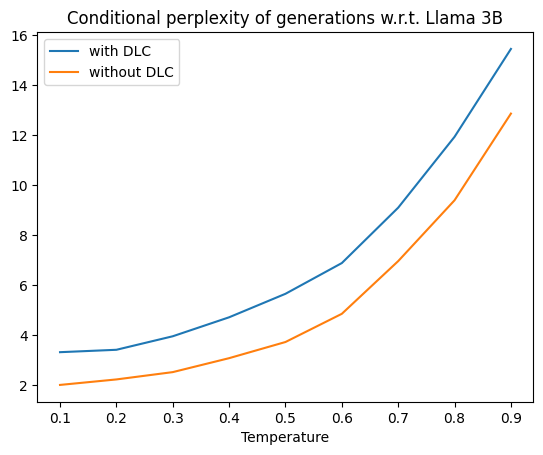

In [91]:
plt.plot([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9], torch.Tensor(res), label='with DLC')
plt.plot([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9], torch.Tensor(res_base), label='without DLC')
plt.legend()
plt.title('Conditional perplexity of generations w.r.t. Llama 3B')
plt.xlabel('Temperature')

In [108]:
ppl

tensor(5.1578, device='cuda:0')

In [109]:
continuations

[' can’t afford to ignore.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to help.\nThe Mental Health Foundation is here to',
 ' can’t afford to ignore.\nThere are many different types of mental health issues, but they all have one thing in common: they are preventable.\n- 1.1 million Americans have a mental illness.\n- 1.1 million Americans have a mental illness.\n- 1.1 million Americans have a mental illness.\n- 1.1 million Americans have a mental illness.\n- 1.1 million Americans have a mental illness.\n- 1',
 ' can’t afford to ignore.\nIf you’re struggling with a mental illness, or if you’re struggling to cope with it, you’re not alone.\nWe’re here to help.\nWe’re her

In [20]:
continuation = task.decoder.generate(
        prompt=prompt,
        dlc=dlc,
        max_length=task.dataset.max_length,
        gen_kwargs={'do_sample': True, "max_new_tokens": 96}
    )
continuation_str = task.decoder.tokenizer.batch_decode(
    continuation,
    skip_special_tokens=True
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
for i in range(40):
    batch = next(dl)
    prompt = [
        batch["input_ids_dec"][i][
            (batch["info_mask_dec"][i] == InfoLabel.PROMPT.value)
        ].tolist()
        for i in range(len(batch["input_ids_dec"]))
    ]
    prompt_str = task.decoder.tokenizer.batch_decode(prompt, skip_special_tokens=True)

    with torch.inference_mode():
        continuations = task.decoder.tokenizer.batch_decode(
            task.decoder.generate(
                prompt=prompt_same,
                max_length=task.dataset.max_length,
                gen_dlc_len=task.encoder.sem.dlc_len if not task.ar_baseline else None,
                gen_kwargs_dlc={"do_sample": True, "temperature": 1.0},
                gen_kwargs={"do_sample": True, "temperature": 1.0}
            ),
            skip_special_tokens=True,
        )

        # Tokenize the sequences with perplexity model
        ppl_batch = task.ppl_tok.batch_encode_plus(
            [p + c for p, c in zip(prompt_str, continuations)],
            padding=True,
            return_tensors="pt",
            return_offsets_mapping=True,
            add_special_tokens=False,
            return_attention_mask=False,
        ).to(device='cuda')

        # Compute token index where continuation starts
        split_idx = split_index_from_offsets(
            ppl_batch["offset_mapping"],
            [len(p) for p in prompt_str],
        )

        # Setup labels (-100 for prompt and padding)
        labels = ppl_batch["input_ids"].clone()
        labels[labels == task.ppl_tok.pad_token_id] = -100
        for i in range(len(labels)):
            labels[i, : split_idx[i]] = -100

        # Compute conditional perplexity of continuations
        ppl_model = task.ppl_model[0]
        ppl_model.to('cuda')
        ppl = torch.exp(
            ppl_model(input_ids=ppl_batch["input_ids"], labels=labels).loss
        )



In [83]:
def split_index_from_offsets(
    batch_offsets,
    batch_char_prefix_lengths,
):
    B = len(batch_offsets)
    out = []

    for offsets, L in zip(batch_offsets, batch_char_prefix_lengths):
        split_idx = 0
        for i, (start, end) in enumerate(offsets):
            if end < L:
                split_idx = i + 1
            else:
                break
        out.append(split_idx)

    return out

In [84]:
split_idx = split_index_from_offsets(xd["offset_mapping"], [len(p) for p in prompt_str])

In [ ]:
with torch.no_grad():
    ppl_ids = ppl_tok.batch_encode_plus(
        [p + c for p, c in zip(prompt_str, true_cont_str)],
        padding=True,
        return_tensors="pt",
        return_offsets_mapping=True,
        add_special_tokens=False
    )["input_ids"].to('cuda')
    labels = ppl_ids.clone()
    labels[labels == ppl_tok.pad_token_id] = -100
    for i in range(len(labels)):
        labels[i,:split_idx[i]] = -100
    
    ppl_model(input_ids=ppl_ids, labels=labels).loss

tensor(2.3748, device='cuda:0')


In [85]:
ppl_tok.decode(ppl_ids[0, :split_idx[0]])

'One in five adults will be diagnosed with a mental illness this year. The numbers are starting, but they don’t have to be. Mental health is a cause you can support with every stride. Hope Network'

In [86]:
prompt_str[0]

'One in five adults will be diagnosed with a mental illness this year. The numbers are starting, but they don’t have to be. Mental health is a cause you can support with every stride. Hope Network'

In [72]:
targets = ppl_ids[:, 1:].contiguous()
logits = logits[:, :-1].contiguous()
loss = torch.nn.functional.cross_entropy(
    logits.view(-1, logits.size(-1)),
    targets.view(-1),
    reduction="none",
).view_as(targets)

In [73]:
loss[targets == ppl_tok.pad_token_id] = 0.0
for i in range(len(loss)):
    loss[i, :split_idx[i]] = 0.0

In [80]:
torch.mean(loss.sum(-1)/torch.sum(loss != 0.0, dim=-1))

tensor(2.3477, device='cuda:0', dtype=torch.float16)

In [68]:
ppl_tok.decode(targets[0, split_idx[0] - 2:])

'’s One in Five Marathon Relay takes place on Friday, June 8 at twilight. Consider joining the cause and running with your friends to support mental health.\nHope Network One in Five Marathon Relay\nFriday, June 8, 2018\nGrand Rapids, Michigan\nFor more information, visit: 1in5marathonrelay.com<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>'

In [69]:
true_cont_str[0]

'’s One in Five Marathon Relay takes place on Friday, June 8 at twilight. Consider joining the cause and running with your friends to support mental health.\nHope Network One in Five Marathon Relay\nFriday, June 8, 2018\nGrand Rapids, Michigan\nFor more information, visit: 1in5marathonrelay.com'

In [ ]:
torch.nn.functional.cross_entropy()

In [ ]:
# shift for causal LM: predict token t from position t-1
logits_shifted = logits[:, :-1]
labels_shifted = ppl_ids[:, 1:]

log_probs = torch.nn.functional.log_softmax(logits_shifted, dim=-1)
suffix_log_probs = log_probs[0, len(prefix_ids)-1:-1, :]  # positions that predict suffix tokens
suffix_labels = labels_shifted[0, len(prefix_ids)-1:]     # suffix token ids

token_logps = suffix_log_probs.gather(-1, suffix_labels.unsqueeze(-1)).squeeze(-1)

tensor([[[ 4.5156,  4.7031,  3.6543,  ..., -4.9805, -4.9805, -4.9805],
         [ 6.8984,  7.6797,  3.5195,  ..., -3.4160, -3.4160, -3.4160],
         [ 8.8594, 10.4219,  4.3906,  ..., -4.3398, -4.3398, -4.3398],
         ...,
         [ 2.6016,  1.1348,  5.6445,  ..., -2.5352, -2.5352, -2.5352],
         [ 2.6445,  1.0957,  5.6055,  ..., -2.5430, -2.5430, -2.5430],
         [ 2.7070,  1.0811,  5.6289,  ..., -2.5938, -2.5938, -2.5957]],

        [[ 4.0664,  4.1992,  4.8438,  ..., -5.2227, -5.2227, -5.2227],
         [ 3.8691,  1.1455,  2.8984,  ..., -4.2969, -4.2969, -4.2969],
         [ 1.7070, -2.0645,  1.7100,  ..., -2.7891, -2.7871, -2.7871],
         ...,
         [ 8.8984,  7.6602,  6.9766,  ..., -4.6562, -4.6562, -4.6562],
         [ 5.7422,  8.5547,  2.9102,  ..., -3.3613, -3.3613, -3.3633],
         [ 7.0391,  6.0703,  4.8438,  ..., -3.8340, -3.8340, -3.8359]],

        [[ 4.1367,  4.3906,  4.0312,  ..., -4.7227, -4.7227, -4.7227],
         [ 7.3320,  7.3047,  5.7734,  ..., -3

In [30]:
ppl_model(input_ids=ppl_ids, labels=labels).loss

tensor(2.3748, device='cuda:0', grad_fn=<NllLossBackward0>)

In [39]:
ppl_tok.batch_decode([xd["input_ids"][i, split_idx[i]:] for i in range(5)])

[' you can support with every stride. Hope Network’s One in Five Marathon Relay takes place on Friday, June 8 at twilight. Consider joining the cause and running with your friends to support mental health.\nHope Network One in Five Marathon Relay\nFriday, June 8, 2018\nGrand Rapids, Michigan\nFor more information, visit: 1in5marathonrelay.com<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>',
 ' behind them.\nThese are not college students looking for a part time job. That\'s why we are "Entertainers" not just DJ\'s. This expertise doesn\'t cost more than the average DJ does. When it comes to your event, you get more for your dollar!!\nWe are "Your Entertaining Entertainers". We a

In [65]:
token_index = next(i for i, (a, b) in enumerate(xd["offset_mapping"][0]) if a <= 236 < b)

In [66]:
token_index

50

In [69]:
ppl_tok.decode(xd["input_ids"][0,50:])

'Authorized, the word to be an a, the word, an an was an to not be an the a word, the, the, the, the,\n to be, an to be, the, the, the, the, the, the, the, the, the, the, the word word to to be, the, the, the, the, the word word to be, the, the, the word to be, the, word to be<|end_of_text|><|end_of_text|>'

In [70]:
continuation_str[0]

'Authorized, the word to be an a, the word, an an was an to not be an the a word, the, the, the, the,\n to be, an to be, the, the, the, the, the, the, the, the, the, the, the word word to to be, the, the, the, the, the word word to be, the, the, the word to be, the, word to be'

In [57]:
len(prompt[0])

55

In [49]:
xd["offset_mapping"].shape

torch.Size([5, 152, 2])

In [22]:
xd = ppl_tok.batch_encode_plus(prompt_str, padding=True, return_tensors='pt')

In [15]:
batch_ = task.decoder.tokenizer.pad(
    {"input_ids": [p + [task.decoder.tokenizer.bos_token_id] for p in prompt]},
    padding=True,
    padding_side="left",
    return_tensors="pt",
).to('cuda')
gen_cfg = {
    "max_new_tokens": 96,  # 32-token DLC + closing <|bos|>
    "do_sample": False,
    "top_p": 1.0,
    "top_k": 50,
    "num_beams": 1,
    "temperature": 1.0,
    "return_dict_in_generate": True,
    "pad_token_id": task.decoder.tokenizer.pad_token_id,
    "eos_token_id": task.decoder.tokenizer.eos_token_id,
    "use_cache": True,
}

task.decoder.tokenizer.batch_decode(task.decoder.backbone.generate(
    **batch_,
    generation_config=GenerationConfig(**gen_cfg),
).sequences)[0]

'One in five adults will be diagnosed with a mental illness this year. The numbers are starting, but they don’t have to be. Mental health is a cause<|think|><|endoftext|> of so much suffering and so much loss.\nThe Mental Health Awareness Week is on March 5-7, 2014. The Mental Health Awareness Week is a week-long celebration of mental health.\nThe Mental Health Awareness Week is on March 5-7, 2014.\nThe Mental Health Awareness Week is on March 5-7, 2014.\nFor more information, visit the Mental Health Awareness Week website.\nFor more information, visit the Mental Health Awareness Week website.\n'

In [17]:
tok = task.decoder.tokenizer
model = task.decoder.backbone

In [21]:
prompt = [p + [tok.bos_token_id] for p in prompt]

In [59]:
batch = tok.pad({"input_ids": prompt}, padding=True, padding_side='left', return_tensors='pt').to('cuda')

In [10]:
model.config.pad_token_id = tok.pad_token_id
model.config.vocab_size = len(model.transformer.wte.weight)

In [26]:
batch["input_ids"][0]

tensor([ 3198,   287,  1936,  6490,   481,   307, 14641,   351,   257,  5110,
         8526,   428,   614,    13,   383,  3146,   389,  3599,    11,   475,
          484,   836,   447,   247,    83,   423,   284,   307,    13, 21235,
         1535,   318,   257,  2728,   345,   460,  1104,   351, 50258, 50299,
        50288, 50287, 50287, 50312, 50288, 50302, 50296, 50294, 50274, 50262,
        50291, 50322, 50315, 50315, 50311, 50302, 50314, 50262, 50305, 50321,
        50262, 50310, 50311, 50266, 50315, 50263, 50261, 50312, 50301, 50265,
        50260, 50320, 50276, 50303, 50307, 50302, 50321, 50285, 50260, 50283,
        50319, 50288, 50284, 50294, 50311, 50302, 50269, 50272, 50302, 50318,
        50289, 50263, 50259, 50305, 50304, 50297, 50277, 50284, 50307, 50300,
        50272, 50297, 50297, 50256], device='cuda:0')

In [27]:
batch["attention_mask"][0]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')

In [63]:
gen_cfg = {
    "max_new_tokens": 96,  # 32-token DLC + closing <|bos|>
    "do_sample": False,
    "top_p": 1.0,
    "top_k": 50,
    "num_beams": 1,
    "temperature": 1.0,
    "return_dict_in_generate": True,
    "pad_token_id": tok.pad_token_id,
    "eos_token_id": tok.eos_token_id,
    "use_cache": True,
    "return_attention": True
}
continuation_bad = model.generate(**batch,generation_config=GenerationConfig(**gen_cfg))
continuation = model.generate(input_ids = batch["input_ids"][0][batch["attention_mask"][0].bool()][None],generation_config=GenerationConfig(**gen_cfg))

print("without padding: ", tok.decode(continuation.sequences[0]))
print("with padding: ", tok.decode(continuation_bad.sequences[0]))

without padding:  One in five adults will be diagnosed with a mental illness this year. The numbers are starting, but they don’t have to be. Mental health is a cause you can support with every stride. Hope Network’s One in Five Marathon Relay takes place on Friday, June 8<|think|><|endoftext|>, at 7:30 a.m. and is a great way to support mental health awareness and awareness of mental illness.
One in Five Marathon Relay
June 8, 2017
Hope Network, Inc.
For more information, please visit www.HopeNetwork.org.
For more information, please call (800) 852-5100.
Hope Network, Inc.
P.O. Box 515
Canton, OH 44142
Copyright
with padding:  One in five adults will be diagnosed with a mental illness this year. The numbers are starting, but they don’t have to be. Mental health is a cause you can support with every stride. Hope Network’s One in Five Marathon Relay takes place on Friday, June 8<|think|><|endoftext|>, at 7:30 a.m. and is a great way to support mental health awareness and awareness of men

In [64]:
continuation

GenerateDecoderOnlyOutput(sequences=tensor([[ 3198,   287,  1936,  6490,   481,   307, 14641,   351,   257,  5110,
          8526,   428,   614,    13,   383,  3146,   389,  3599,    11,   475,
           484,   836,   447,   247,    83,   423,   284,   307,    13, 21235,
          1535,   318,   257,  2728,   345,   460,  1104,   351,   790, 33769,
            13, 13408,  7311,   447,   247,    82,  1881,   287, 10579, 24828,
          4718,   323,  2753,  1295,   319,  3217,    11,  2795,   807, 50258,
         50280, 50288, 50275, 50281, 50278, 50288, 50314, 50284, 50298, 50274,
         50305, 50267, 50322, 50286, 50318, 50305, 50305, 50314, 50262, 50297,
         50306, 50262, 50287, 50278, 50280, 50315, 50296, 50261, 50290, 50301,
         50265, 50288, 50320, 50276, 50303, 50293, 50293, 50307, 50285, 50260,
         50283, 50320, 50281, 50284, 50294, 50311, 50262, 50269, 50287, 50296,
         50290, 50305, 50283, 50259, 50312, 50294, 50266, 50303, 50284, 50307,
         50298, 

In [11]:
input_ids = batch["input_ids"][0]
mask = batch["attention_mask"][0]

In [12]:
position_ids = (mask.cumsum(-1) - 1).clamp(min=0)
position_ids = position_ids * mask  # 0 on pads, 0..L-1 on tokens

In [25]:
model.config.use_cache = False

In [42]:
model = model.to(dtype=torch.bfloat16)

In [50]:
model.set_attn_implementation("sdpa")

In [51]:
print(input_ids[mask.bool()])
print(position_ids[mask.bool()])
out1 = model(input_ids=input_ids[None], attention_mask=mask[None], position_ids=position_ids[None])
out1.logits[0,-1].argmax()

tensor([ 3198,   287,  1936,  6490,   481,   307, 14641,   351,   257,  5110,
         8526,   428,   614,    13,   383,  3146,   389,  3599,    11,   475,
          484,   836,   447,   247,    83,   423,   284,   307,    13, 21235,
         1535,   318,   257, 50258, 50299, 50288, 50287, 50287, 50312, 50288,
        50302, 50280, 50294, 50274, 50319, 50267, 50322, 50315, 50315, 50311,
        50302, 50296, 50262, 50305, 50321, 50291, 50268, 50295, 50266, 50315,
        50263, 50299, 50301, 50301, 50265, 50285, 50320, 50276, 50303, 50307,
        50302, 50319, 50285, 50309, 50283, 50269, 50288, 50284, 50294, 50311,
        50302, 50269, 50311, 50302, 50318, 50289, 50283, 50259, 50305, 50304,
        50318, 50277, 50284, 50307, 50279, 50306, 50297, 50297, 50256],
       device='cuda:0')
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44

tensor(2219, device='cuda:0')

In [52]:
print(input_ids[mask.bool()][None])
out2 = model(input_ids=input_ids[mask.bool()][None])
out2.logits[0,-1].argmax()

tensor([[ 3198,   287,  1936,  6490,   481,   307, 14641,   351,   257,  5110,
          8526,   428,   614,    13,   383,  3146,   389,  3599,    11,   475,
           484,   836,   447,   247,    83,   423,   284,   307,    13, 21235,
          1535,   318,   257, 50258, 50299, 50288, 50287, 50287, 50312, 50288,
         50302, 50280, 50294, 50274, 50319, 50267, 50322, 50315, 50315, 50311,
         50302, 50296, 50262, 50305, 50321, 50291, 50268, 50295, 50266, 50315,
         50263, 50299, 50301, 50301, 50265, 50285, 50320, 50276, 50303, 50307,
         50302, 50319, 50285, 50309, 50283, 50269, 50288, 50284, 50294, 50311,
         50302, 50269, 50311, 50302, 50318, 50289, 50283, 50259, 50305, 50304,
         50318, 50277, 50284, 50307, 50279, 50306, 50297, 50297, 50256]],
       device='cuda:0')


tensor(2219, device='cuda:0')

In [21]:
print(input_ids[mask.bool()][None])
out3 = model(input_ids=input_ids[None])
out3.logits[0,-1].argmax()

tensor([[ 3198,   287,  1936,  6490,   481,   307, 14641,   351,   257,  5110,
          8526,   428,   614,    13,   383,  3146,   389,  3599,    11,   475,
           484,   836,   447,   247,    83,   423,   284,   307,    13, 21235,
          1535,   318,   257, 50258, 50299, 50288, 50287, 50287, 50312, 50288,
         50302, 50280, 50294, 50274, 50319, 50267, 50322, 50315, 50315, 50311,
         50302, 50296, 50262, 50305, 50321, 50291, 50268, 50295, 50266, 50315,
         50263, 50299, 50301, 50301, 50265, 50285, 50320, 50276, 50303, 50307,
         50302, 50319, 50285, 50309, 50283, 50269, 50288, 50284, 50294, 50311,
         50302, 50269, 50311, 50302, 50318, 50289, 50283, 50259, 50305, 50304,
         50318, 50277, 50284, 50307, 50279, 50306, 50297, 50297, 50256]],
       device='cuda:0')


tensor(2219, device='cuda:0')

In [199]:
model.config.use_cache=False

In [205]:
out1, out2

(CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[-0.7578,  2.3125, -2.3281,  ..., -3.4219, -1.6719, -3.9375],
          [-0.7578,  2.3125, -2.3281,  ..., -3.4219, -1.6719, -3.9375],
          [-0.7578,  2.3125, -2.3281,  ..., -3.4219, -1.6719, -3.9375],
          ...,
          [ 4.7812,  1.0234,  2.5781,  ..., -0.3262,  1.0938,  0.1367],
          [ 4.5938,  0.4551,  2.0938,  ..., -1.0000,  0.3945, -0.5625],
          [ 4.1250,  0.1670,  1.6016,  ..., -1.7891, -0.5117, -1.2578]]],
        device='cuda:0', dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>), past_key_values=None, hidden_states=None, attentions=None, cross_attentions=None),
 CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[-0.5898,  1.7344, -0.5352,  ..., -3.2344, -2.1875, -3.6562],
          [ 1.2578, -0.1396, -3.0469,  ..., -4.3438, -3.9219, -4.7500],
          [ 2.6094,  0.5703, -2.6406,  ..., -4.4688, -3.5625, -4.4688],
          ...,
          [-2.4844, -3.9844, -5.2188,  ..., 14.6250, 1

In [143]:
model.get_input_embeddings().num_embeddings-len(tok)

64

50259

'[PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD]One in five adults will be diagnosed with a mental illness this year. The numbers are starting, but they don’t have to be. Mental health is a cause you can support with every stride. Hope Network’s One<|think|><|endoftext|> (That Day (Posted the Angry With A (This April F (Posted After More\nFriday('

'One in five adults will be diagnosed with a mental illness this year. The numbers are starting, but they don’t have to be. Mental health is a cause you can support with every stride. Hope Network’s One<|think|><|endoftext|> in Five Campaign will raise awareness during February through March.\nTogether, raise awareness, encourage conversation and'

In [38]:
data = FineWebDataset(length_interval=[32, 96])

Resolving data files:   0%|          | 0/824 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/828 [00:00<?, ?it/s]

In [44]:
batch = data.__getitems__([0,1,2,3,4,5,6,7,8,9,10,11,12])

In [207]:
from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device='cuda')

# We recommend enabling flash_attention_2 for better acceleration and memory saving,
# together with setting `padding_side` to "left":
# model = SentenceTransformer(
#     "Qwen/Qwen3-Embedding-0.6B",
#     model_kwargs={"attn_implementation": "flash_attention_2", "device_map": "auto"},
#     tokenizer_kwargs={"padding_side": "left"},
# )

In [208]:
#prompt = "Represent the text with high-level features. This can include semantic information, type of text, intent, style. Text: "
#prompt = "Instruct: Represent the text with high-level features. This can include semantic information, type of text, intent, style.\nText: "
prompt = None
query_embeddings = model.encode(batch["input_str"], prompt=prompt)
document_embeddings = model.encode(batch["input_str"], prompt=prompt)
similarity = model.similarity(query_embeddings, document_embeddings)
similarity.fill_diagonal_(-torch.inf);

In [204]:
batch["input_str"][1]

"\nI'm not going to lie to you and say that I loved everything about it (3:00 AM wake up calls being the main offender), but I was consistently surprised to find that even in the tougher times, when we had been blearily working for 18 hours straight, something or someone would come along to pick everyone up.\nFrom the absolute chaos of pre-show preparations,"

In [206]:
batch["input_str"][8]

' making Monday nights on SPEED interesting again. It also helped that the network executives finally relented and let the race review lead the show. It made a big difference.\nThis week, Byrnes, Waltrip and Knaus were all tired from a long California weekend and a three hour time zone shift. Waltrip started slow, but got himself back on-track by suggesting California go to'

In [205]:
torch.softmax(similarity/0.01,-1)[1].argsort(descending=True)

tensor([ 8,  9,  7, 11,  6, 12, 10,  3,  2,  4,  5,  0,  1])

In [210]:
torch.softmax(similarity/0.01,-1)[0].argsort(descending=True)

tensor([ 7, 12,  2, 10,  1,  9, 11,  4,  3,  8,  6,  5,  0])

In [169]:
print("A:" +batch["input_str"][1] + "\nB:" + batch["input_str"][6])

A:
I'm not going to lie to you and say that I loved everything about it (3:00 AM wake up calls being the main offender), but I was consistently surprised to find that even in the tougher times, when we had been blearily working for 18 hours straight, something or someone would come along to pick everyone up.
From the absolute chaos of pre-show preparations,
B:ly got 28 first-place votes versus only 11 for Wagner.
At times like these I can imagine some fans crying about an East Coast bias within the media, but I'm not sure how much I buy that here given the fact that the


In [164]:
# The queries and documents to embed
queries = [
    "Then, I went to the garden to the garden to pick some cherries.",
    "Explain gravity.",
]
documents = [
    "Last, year, diego went to Africa to meet an old friend.",
    "Gravity is a force that attracts two bodies towards each other.",
    "I love going in the forest and foraging mushrooms!",
    "You love going in the forest and foraging mushrooms!",
    "Can you explain the maillard reaction?",
    "Explain why the sky is blue.",
    "Yesterday, I went to the store to buy some things."
]
prompt = None

#prompt = "Instruct: Given some text, retrieve other texts which share some high level attributes. This can include semantic information, type of text, intent, style. \nText:"
prompt = "Represent the text with high-level features. This can include semantic information, type of text, intent, style. Text: "
#prompt = "Instruct: Given some text taken from the internet, retrieve other similar text. Text: "
#prompt = "Instruct: Represent the following passage with its high-level features. This can include semantic information, type of text, intent, style.\nText: "
#prompt = "Instruct: Represent the following text "
query_embeddings = model.encode(queries, prompt=prompt)
document_embeddings = model.encode(documents, prompt=prompt)

In [165]:
similarity = model.similarity(query_embeddings, document_embeddings)
similarity

tensor([[0.8175, 0.8386, 0.9061, 0.8952, 0.8412, 0.8487, 0.8798],
        [0.8261, 0.9366, 0.9186, 0.9336, 0.9719, 0.9821, 0.8365]])

In [166]:
torch.softmax(similarity/0.1,-1)

tensor([[0.0882, 0.1089, 0.2141, 0.1919, 0.1119, 0.1206, 0.1645],
        [0.0509, 0.1537, 0.1284, 0.1492, 0.2189, 0.2424, 0.0565]])

In [153]:
import torch

In [15]:
x = torch.IntTensor([[1,2,3],[4,5,6]])
prompt = [3,3,4,4]

In [22]:
[[] for i in range(10)]

[[], [], [], [], [], [], [], [], [], []]

In [18]:
torch.cat([x,y])

RuntimeError: Tensors must have same number of dimensions: got 2 and 1

In [7]:
[prompt + x]

TypeError: can only concatenate list (not "Tensor") to list